In [1]:
using Lux, Reactant, Enzyme, Zygote, Optimisers, MLUtils, Random, Statistics, JLD2, Plots, NNlib, ProgressMeter, BSON
include("analysis_tools.jl")
include("models.jl")

const cdev = cpu_device()
const xdev = reactant_device(; force=true);

In [2]:
# Settings
epochs = 1000
batchsize = 40
learning_rate = 0.005f0

seed = 0
#ad_backend = AutoZygote() # Reactant does not like zygote, cpu does not like enzyme
ad_backend = AutoEnzyme()


n_hidden = 8
n_filter = 3;

In [3]:
trainpaths = [
    "data/burgers1d_periodicNoised_dt1.jld2", 
    "data/burgers1d_periodicNoised_dt2.jld2",
    "data/burgers1d_periodicNoised_dt3.jld2",
    "data/burgers1d_periodicNoised_dt4.jld2",
    "data/burgers1d_periodicNoised_dt5.jld2"
]
truthpaths = [
    "data/burgers1d_periodicBase_dt1.jld2", 
    "data/burgers1d_periodicBase_dt2.jld2",
    "data/burgers1d_periodicBase_dt3.jld2",
    "data/burgers1d_periodicBase_dt4.jld2",
    "data/burgers1d_periodicBase_dt5.jld2"
]
pairs_per_set = 100
(X, Δt), y, Xμ, Xσ = generate_datasets(trainpaths, truthpaths, pairs_per_set)

dataloader = DataLoader(((X, Δt), y), batchsize=batchsize, shuffle=true, partial=false) |> xdev;

In [4]:
function loss_function(model, ps, st, ((X_batch, Δt_batch), y_batch))
    y_pred, _ = model((X_batch, Δt_batch), ps, st)
    
    data_loss = mean(abs2, y_pred .- y_batch)
    loss = data_loss
    return loss, st, (; data_loss, total_loss=loss)
end;

In [5]:
time_model = TimeModel(n_filter, n_hidden)

rng = Random.default_rng()
Random.seed!(rng, seed)

ps, st = Lux.setup(rng, time_model) |> xdev

train_state = Training.TrainState(time_model, ps, st, Adam(learning_rate))

lr = i -> i < 500 ? 0.005f0 : (i < 1000 ? 0.0005f0 : 0.00005f0)

total_losses = Float32[]
data_losses = Float32[]

count = 0
@showprogress for epoch in 1:epochs
    Optimisers.adjust!(train_state, lr(epoch))
    for batch in dataloader
        _, loss, stats, train_state = Training.single_train_step!(ad_backend,
                                                              loss_function,
                                                              batch,
                                                              train_state;
                                                              return_gradients=Val(false),
        )
        if count % 100 == 0
            push!(total_losses, stats.total_loss)
            push!(data_losses, stats.data_loss)
        end
        count+=1
    end
end

model = StatefulLuxLayer(time_model, cdev(train_state.parameters), cdev(train_state.states));
BSON.@save "models/trained_model_trial.bson" model Xμ Xσ;

I0000 00:00:1758977862.556015   26514 service.cc:163] XLA service 0x3bfba610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758977862.556040   26514 service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
I0000 00:00:1758977862.556300   26514 se_gpu_pjrt_client.cc:1338] Using BFC allocator.
I0000 00:00:1758977862.556325   26514 gpu_helpers.cc:136] XLA backend allocating 6159925248 bytes on device 0 for BFCAllocator.
I0000 00:00:1758977862.556349   26514 gpu_helpers.cc:177] XLA backend will use up to 2053308416 bytes on device 0 for CollectiveBFCAllocator.
I0000 00:00:1758977862.565172   26514 cuda_dnn.cc:463] Loaded cuDNN version 90800
Progress: 100%|█████████████████████████████████████████| Time: 0:01:06


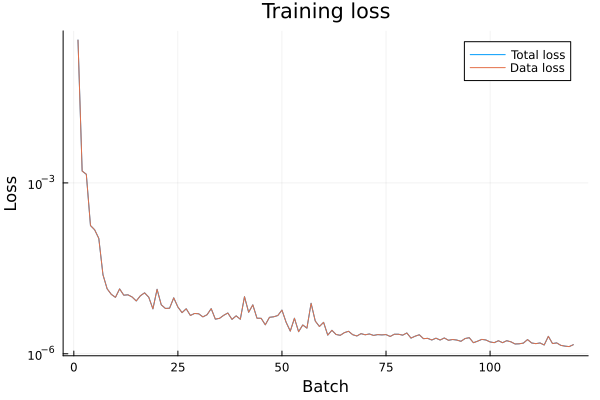

In [6]:
p1 = plot(total_losses, label="Total loss", xlabel="Batch", ylabel="Loss", yscale=:log10, title="Training loss")
plot!(p1, data_losses, label="Data loss")
display(p1)